<a href="https://colab.research.google.com/github/alexanderjsturgill/IT480-FA26/blob/main/Assignment1_hyperparameter_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
def plot_history(history, title, show_accuracy=False):
    if show_accuracy:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(history.history["loss"], label="Training Loss")
        axes[0].plot(history.history["val_loss"], label="Validation Loss")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
        axes[0].set_title(title + " -- Loss")

        axes[1].plot(history.history["accuracy"], label="Training Accuracy")
        axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
        axes[1].set_title(title + " -- Accuracy")
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(6, 4))
        plt.plot(history.history["loss"], label="Training Loss")
        plt.plot(history.history["val_loss"], label="Validation Loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss (MSE, scaled)"); plt.title(title); plt.legend()
        plt.show()

In [3]:
wine = fetch_openml(name="wine-quality-red", version=1, as_frame=True, parser="auto")
df3 = wine.frame

print(df3.shape)
print(df3["class"].astype(int).value_counts().sort_index())

(1599, 12)
class
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [4]:
# Bucket raw quality scores into 3 bands: low / medium / high
def bucket_quality(q):
    q = int(q)
    if q <= 5:
        return 0  # low
    elif q == 6:
        return 1  # medium
    else:
        return 2  # high

df3["quality_band"] = df3["class"].apply(bucket_quality)
print(df3["quality_band"].value_counts().sort_index())

# Q: How many classes do we have now? Are they reasonably balanced?
# Your answer: We have 3 classes, they are not reasonably balanced as both class 0 and 1 are relatively balanced (744 and 638 respectively) but not in
# comparison to class 2 (217).

quality_band
0    744
1    638
2    217
Name: count, dtype: int64


In [5]:
X3 = df3.drop(columns=["class", "quality_band"]).values.astype(float)
y3 = df3["quality_band"].values.astype(int)

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

x3_scaler = StandardScaler()
X3_train_scaled = x3_scaler.fit_transform(X3_train)
X3_test_scaled = x3_scaler.transform(X3_test)

In [6]:
n_classes = len(np.unique(y3))

# Create the classification model
model_multi = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation="relu", input_shape=(X3_train_scaled.shape[1],)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(n_classes, activation="softmax")
])

model_multi.compile(optimizer= "adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


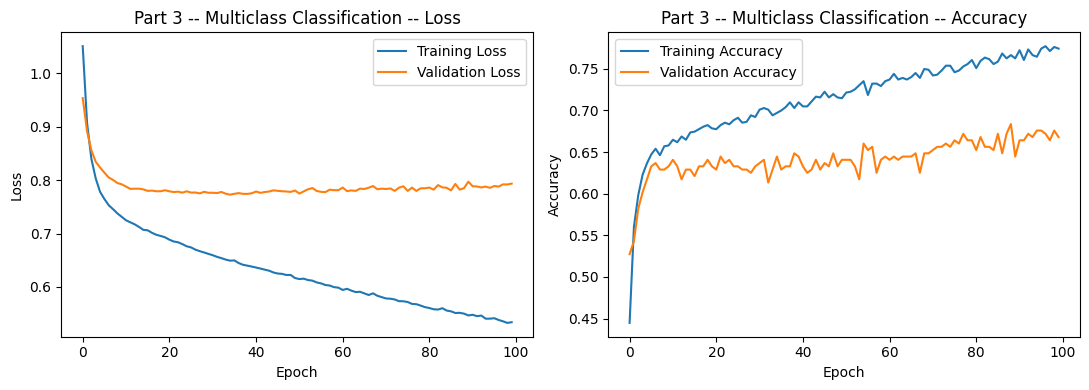

In [7]:
history_multi = model_multi.fit(
    X3_train_scaled, y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(history_multi, "Part 3 -- Multiclass Classification", show_accuracy=True)

In [8]:
multi_probs = model_multi.predict(X3_test_scaled)
multi_preds = np.argmax(multi_probs, axis=1)

acc_multi = accuracy_score(y3_test, multi_preds)
print(f"Part 3 -- Test Accuracy: {acc_multi:.3f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step  
Part 3 -- Test Accuracy: 0.650


Part 1:

Q1: Done

Q2: The Test Accuracy was 0.650. The Loss Curves looked like two exponention functions that were decreasing with the validation loss leveling out and the training loss continuing to decrease over time. It showed Overfitting with the two curve drifting away from each other starting around the 20 epoch. The validation loss stagnated whilst the training loss continued to decrease.

In [9]:
!pip install keras-tuner --quiet
import keras_tuner as kt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.0 MB/s eta 0:00:00


In [19]:
def build_model(hp):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(
            units=hp.Int("hidden1", min_value=16, max_value=128, step=16),
            activation="relu",
            input_shape=(n_features,)
        ),
        tf.keras.layers.Dense(
            units=hp.Int("hidden2", min_value=8, max_value=64, step=8),
            activation="relu"
        ),
        tf.keras.layers.Dense(n_classes, activation="softmax")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            hp.Choice("learning_rate", [0.001, 0.01, 0.1])
            ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
        )
    return model

In [22]:
n_features = X3_train_scaled.shape[1]
tuner = kt.RandomSearch(
build_model,
objective="val_loss",
max_trials=5,
overwrite=True
)

tuner.search(
X3_train_scaled, y3_train,
validation_split=0.2, epochs=50, verbose=0
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
best_model = tuner.get_best_models(num_models=1)[0]
best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

{'hidden1': 96, 'hidden2': 48, 'learning_rate': 0.001}


In [26]:
best_model.fit(X3_train_scaled, y3_train, validation_split=0.2, epochs=100, verbose=0)
tuned_test_loss, tuned_test_acc = best_model.evaluate(X3_test_scaled, y3_test, verbose=0)
print(f"\nTuned Model Test Accuracy: {tuned_test_acc:.4f}")


Tuned Model Test Accuracy: 0.6562


The model improved accuray by just 0.0062 from our first set.

In [28]:
model_drop = tf.keras.Sequential([
tf.keras.layers.Dense(
64, activation="relu", input_shape=(n_features,)
),
tf.keras.layers.Dropout(0.3),
tf.keras.layers.Dense(32, activation="relu"),
tf.keras.layers.Dropout(0.3),
tf.keras.layers.Dense(n_classes, activation="softmax")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [47]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
    )

model_drop.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model_drop.fit(
    X3_train_scaled, y3_train,
    validation_split=0.2,
    epochs=200,
    callbacks=[early_stop],
    verbose=0
    )

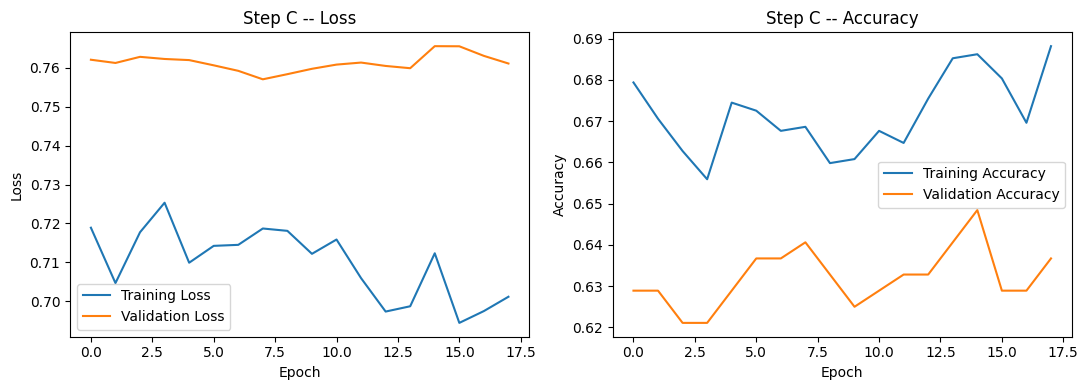

In [48]:
plot_history(history, "Step C", show_accuracy=True)

The gap between training and validation loss grew and the validation loss was very high. Honestly we were very confused on this portion.

In [56]:
final_acc = model_drop.evaluate(X3_test_scaled, y3_test, verbose=0)
print(f"Final Test Accuracy: {final_acc[1]:.4f}")

Final Test Accuracy: 0.6719


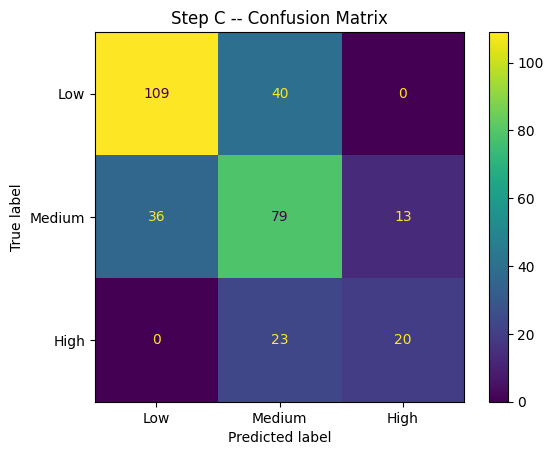

In [62]:
cm3 = confusion_matrix(y3_test, multi_preds)
ConfusionMatrixDisplay(cm3, display_labels=["Low", "Medium", "High"]).plot()
plt.title("Step C -- Confusion Matrix")
plt.show()

The model prediction has remained around the same compared to the Lab 1 Confusion matrix. The Test Accuracy improvated by 0.0219 from Lab one to 0.6719.

Part D: Reflection

1. It is important that our test set was only touched once because it helps to ensure that our model relies on genuine unseen data rather than data that we have manipulated by touching it which can influence the outcome.

2. If we had used our test set to pick the best hyperparemeters, our test set effectively becomes part of the training set. This can lead to our model to skew towards the best test set model performance but again it will not hold up this performance when attempting on real life models.

3. Whilst we had issues in understanding how to properly implement Dropout and Early Stopping, in theory they should help to reduce the overiffiting. Early Stopping stops the training when the validation loss reaches its minimum value which minimizes distance between loss curves. Dropout helps to prevent over-reliance on specific neurons by randomly turning some off during the training which should further narrow the distance between the loss curves caused by over-reliance.

4. Given unlimited time and compute, we'd want to have much larger data sets in order to more accurately extrapolate data from this set. Additionally, we'd want to broaden our hyperparameters given the infinite time and computing time so that we can have the model attempt to classify and predict from these broad classes.


We had a rather difficult time attempting to grasp this assignment especially with the implementation of the models so it would be incredibly beneficial to go over this in class as we felt pretty lost.